# Линейная регрессия с нуля

Реализация градиентного спуска с L2-регуляризацией (Ridge).  
Верификация: сравнение весов с `sklearn.linear_model.Ridge`, отклонение < 0.001.

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.linear_model import Ridge

In [14]:
class LinearRegressionGD:
    """
    Линейная регрессия через градиентный спуск с L2-регуляризацией.
    """

    def __init__(self, lr=0.01, n_iter=1000, l2=0.0):
        self.lr = lr
        self.n_iter = n_iter
        self.l2 = l2
        self.w = None
        self.loss_history = []

    def fit(self, X, y):
        n, d = X.shape
        X_b = np.hstack([X, np.ones((n, 1))])
        self.w = np.zeros(d + 1)
        self.loss_history = []

        for _ in range(self.n_iter):
            y_pred = X_b @ self.w
            grad = (2 / n) * (X_b.T @ (y_pred - y)) + 2 * self.l2 * self.w
            self.w = self.w - self.lr * grad
            self.loss_history.append(np.mean((y - y_pred) ** 2))

        return self

    def predict(self, X):
        X_b = np.hstack([X, np.ones((X.shape[0], 1))])
        return X_b @ self.w

In [15]:
# Генерируем данные
X, y = make_regression(n_samples=200, n_features=3, noise=10, random_state=42)

# Наша модель
model = LinearRegressionGD(lr=0.1, n_iter=1000, l2=0.1 / 200)
model.fit(X, y)

# sklearn для сравнения
sk_model = Ridge(alpha=0.1)
sk_model.fit(X, y)

print('Наши веса:   ', model.w[:-1])
print('sklearn веса:', sk_model.coef_)
print('Макс. отклонение:', np.max(np.abs(model.w[:-1] - sk_model.coef_)))

Наши веса:    [71.60339706 21.83082529 72.71527676]
sklearn веса: [71.60340408 21.83084138 72.71524962]
Макс. отклонение: 2.7143179877953116e-05


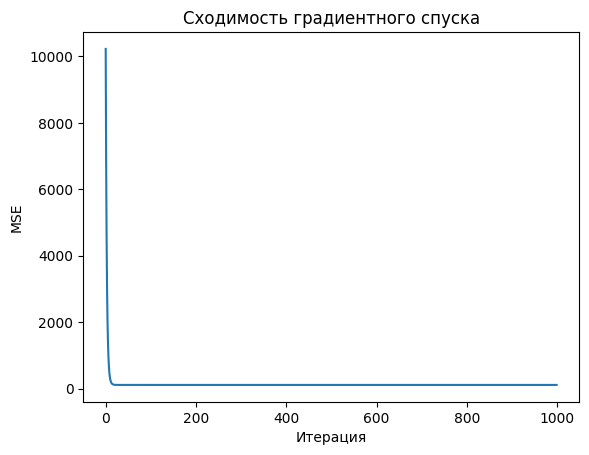

In [16]:
# График сходимости
plt.plot(model.loss_history)
plt.xlabel('Итерация')
plt.ylabel('MSE')
plt.title('Сходимость градиентного спуска')
plt.show()